# Week 13 Exercises

### Ex 13.2

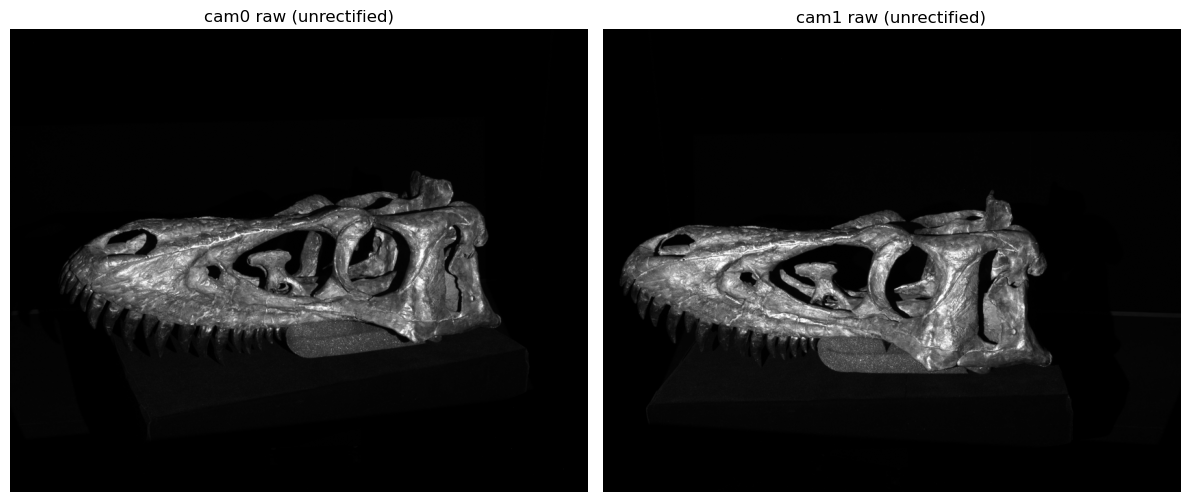

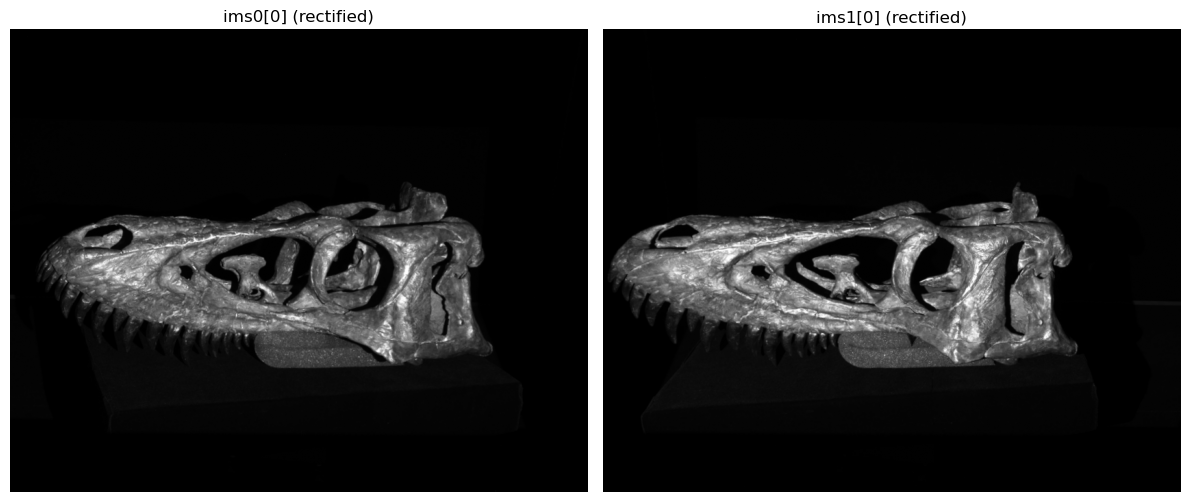

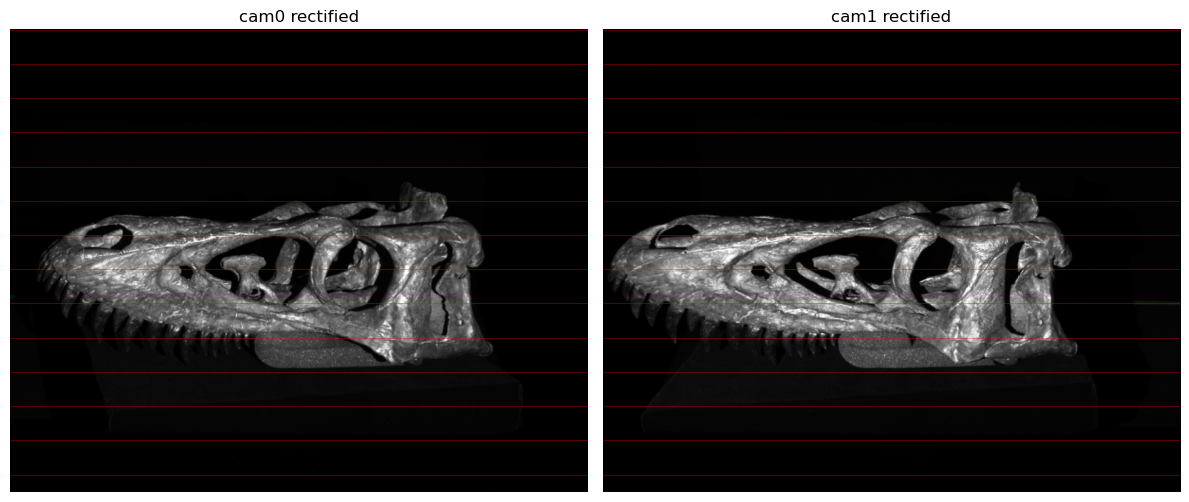

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from CV_functions import *

# --- Load calibration ---
c = np.load('casper/calib.npy', allow_pickle=True).item()

# --- Initialize rectification maps ---
im0 = cv2.imread("casper/sequence/frames0_0.png")
size = (im0.shape[1], im0.shape[0])

stereo = cv2.stereoRectify(c['K0'], c['d0'], c['K1'],
                            c['d1'], size, c['R'], c['t'], flags=0)
R0, R1, P0, P1 = stereo[:4]

maps0 = cv2.initUndistortRectifyMap(c['K0'], c['d0'], R0, P0, size, cv2.CV_32FC2)
maps1 = cv2.initUndistortRectifyMap(c['K1'], c['d1'], R1, P1, size, cv2.CV_32FC2)

def load_gray(path):
    im = cv2.imread(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
    return im

def rectify(im, maps):
    return cv2.remap(im, *maps, cv2.INTER_LINEAR)

# --- Show BEFORE rectification (frame 0, fully illuminated) ---
raw0 = load_gray("casper/sequence/frames0_0.png")
raw1 = load_gray("casper/sequence/frames1_0.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw0, cmap='gray')
axes[0].set_title('cam0 raw (unrectified)')
axes[0].axis('off')
axes[1].imshow(raw1, cmap='gray')
axes[1].set_title('cam1 raw (unrectified)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# --- Load and rectify all 26 images (0-25) for each camera ---
ims0 = []
ims1 = []
for i in range(26):
    ims0.append(rectify(load_gray(f"casper/sequence/frames0_{i}.png"), maps0))
    ims1.append(rectify(load_gray(f"casper/sequence/frames1_{i}.png"), maps1))

# --- Show AFTER rectification ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ims0[0], cmap='gray')
axes[0].set_title('ims0[0] (rectified)')
axes[0].axis('off')
axes[1].imshow(ims1[0], cmap='gray')
axes[1].set_title('ims1[0] (rectified)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# --- Optional: overlay horizontal guide lines to visually confirm rectification ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, im, title in zip(axes, [ims0[0], ims1[0]], ['cam0 rectified', 'cam1 rectified']):
    ax.imshow(im, cmap='gray')
    for y in range(0, im.shape[0], 50):
        ax.axhline(y, color='red', linewidth=0.5, alpha=0.5)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Ex 13.3

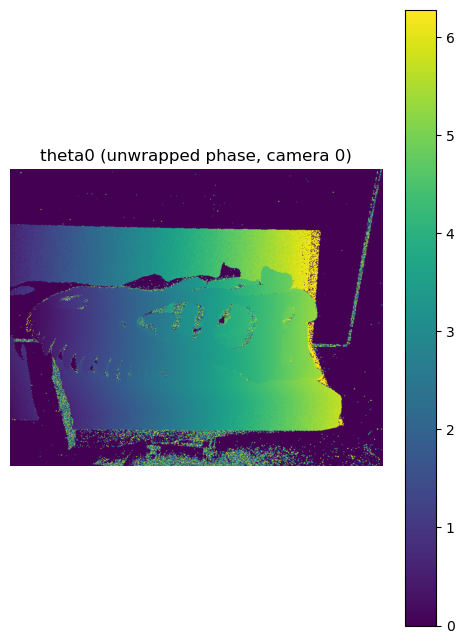

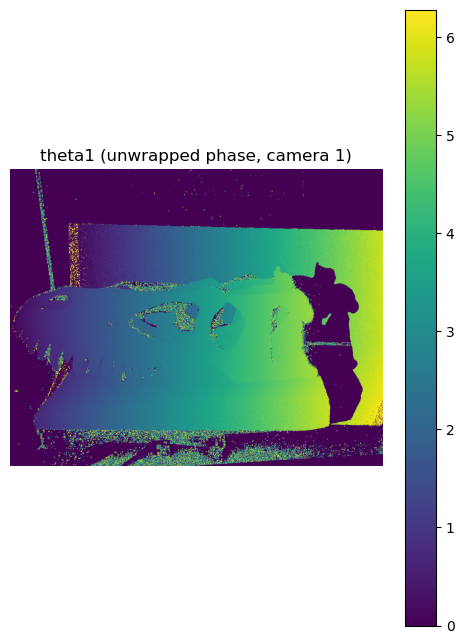

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Pattern parameters (given in the exercise) ---
N1 = 40   # periods in the primary pattern
N2 = 41   # periods in the secondary pattern

def unwrap(ims):
    """
    ims: list/array of 26 rectified, grayscale, float images for one camera
         (indices 0-25 as described in the exercise)
    returns: unwrapped phase map theta, same shape as one image
    """
    ims = np.asarray(ims)

    # --- Primary pattern: images 2-17 (16 images) ---
    primary = ims[2:18]
    assert primary.shape[0] == 16

    fft_primary = np.fft.rfft(primary, axis=0)
    theta_primary = np.angle(fft_primary[1])   # wrapped phase, primary pattern

    # --- Secondary pattern: images 18-25 (8 images) ---
    secondary = ims[18:26]
    assert secondary.shape[0] == 8

    fft_secondary = np.fft.rfft(secondary, axis=0)
    theta_secondary = np.angle(fft_secondary[1])  # wrapped phase, secondary pattern

    # --- Heterodyne: phase cue ---
    theta_c = (theta_secondary - theta_primary) % (2 * np.pi)

    # --- Order of the primary phase (how many times it wrapped) ---
    o_primary = np.round((N1 * theta_c - theta_primary) / (2 * np.pi))

    # --- Unwrapped phase using the primary phase + its order ---
    theta = (2 * np.pi * o_primary + theta_primary) / N1
    theta = theta % (2 * np.pi)

    return theta

# --- Apply to both cameras ---
theta0 = unwrap(ims0)
theta1 = unwrap(ims1)

# --- Visualize ---
plt.figure(figsize=(6, 8))
plt.imshow(theta0, cmap='viridis')
plt.title('theta0 (unwrapped phase, camera 0)')
plt.colorbar()
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 8))
plt.imshow(theta1, cmap='viridis')
plt.title('theta1 (unwrapped phase, camera 1)')
plt.colorbar()
plt.axis('off')
plt.show()